# Paper Similarity — Finding Related Papers

## Goal
Given a query or a paper, find the most semantically similar papers.
This is the foundation of recommendation systems for scientific literature.

## Approach
- Embed paper abstracts using SBERT
- Build FAISS index for fast retrieval
- Query with natural language or another paper's abstract

## Key Question
Can semantic search find related papers without keyword overlap?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss
from sentence_transformers import SentenceTransformer

## 1. Define Paper Corpus
A small corpus of AI papers with abstracts.

In [3]:
papers = [
    {
        "title": "Attention Is All You Need",
        "abstract": "We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. The dominant sequence transduction models are based on complex recurrent or convolutional neural networks. The Transformer allows for significantly more parallelization and achieves state of the art on machine translation tasks."
    },
    {
        "title": "BERT: Pre-training of Deep Bidirectional Transformers",
        "abstract": "We introduce BERT, a new language representation model. BERT stands for Bidirectional Encoder Representations from Transformers. Unlike recent language representation models, BERT is designed to pre-train deep bidirectional representations from unlabeled text by jointly conditioning on both left and right context in all layers."
    },
    {
        "title": "GPT-4: Language Models are Few-Shot Learners",
        "abstract": "We train GPT-3, an autoregressive language model with 175 billion parameters. GPT-3 achieves strong performance on many NLP tasks in the few-shot setting, sometimes outperforming state-of-the-art fine-tuned models. We demonstrate that scaling up language models greatly improves task-agnostic, few-shot performance."
    },
    {
        "title": "Deep Residual Learning for Image Recognition",
        "abstract": "We present a residual learning framework to ease the training of networks that are substantially deeper than those used previously. We explicitly reformulate the layers as learning residual functions with reference to the layer inputs. Our deep residual networks are winners of the ImageNet competition."
    },
    {
        "title": "Generative Adversarial Networks",
        "abstract": "We propose a new framework for estimating generative models via an adversarial process. We simultaneously train two models: a generative model G that captures the data distribution, and a discriminative model D that estimates the probability that a sample came from the training data rather than G."
    },
    {
        "title": "A Survey of Large Language Models",
        "abstract": "Large language models have recently demonstrated remarkable capabilities. These models are trained on massive text corpora and can perform a wide range of NLP tasks without task-specific fine-tuning. This survey reviews the development of LLMs, including GPT, BERT, and their successors."
    },
    {
        "title": "FAISS: A Library for Efficient Similarity Search",
        "abstract": "We present FAISS, a library for efficient similarity search and clustering of dense vectors. It contains algorithms that search in sets of vectors of any size, including ones that do not fit in RAM. It also contains supporting code for evaluation and parameter tuning."
    },
    {
        "title": "Sentence-BERT: Sentence Embeddings using BERT",
        "abstract": "We present Sentence-BERT, a modification of the BERT network that uses siamese and triplet networks to derive semantically meaningful sentence embeddings. This enables BERT to be used for semantic textual similarity, clustering, and information retrieval via cosine similarity."
    },
]

df = pd.DataFrame(papers)
print(f"Total papers: {len(df)}")
for i, row in df.iterrows():
    print(f"{i+1}, {row["title"]}")

Total papers: 8
1, Attention Is All You Need
2, BERT: Pre-training of Deep Bidirectional Transformers
3, GPT-4: Language Models are Few-Shot Learners
4, Deep Residual Learning for Image Recognition
5, Generative Adversarial Networks
6, A Survey of Large Language Models
7, FAISS: A Library for Efficient Similarity Search
8, Sentence-BERT: Sentence Embeddings using BERT


## 2. Embed Abstracts and Build Index

In [4]:
# Load model
print("Loading embedding model...")
model = SentenceTransformer("all-MiniLM-L6-v2")

# Embed abstracts
print("Embedding abstracts...")
embeddings = model.encode(df["abstract"].tolist(), show_progress_bar=False)
embeddings = embeddings.astype(np.float32)

# Build FAISS index
index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)

print(f"\nIndex built.")
print(f"Papers indexed: {index.ntotal}")
print(f"Embedding dimesion: {embeddings.shape[1]}")

Loading embedding model...


README.md: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding abstracts...

Index built.
Papers indexed: 8
Embedding dimesion: 384


## 3. Query The Index

In [5]:
def find_similar_papers(query: str, top_k: int = 3) -> pd.DataFrame:
    """Find most similar papers to a query."""
    query_embeddings = model.encode([query]).astype(np.float32)
    distances, indeces = index.search(query_embeddings, top_k)

    results = []
    for dist, idx in zip(distances[0], indeces[0]):
        results.append({
            "title": df.iloc[idx]["title"],
            "distance": float(dist),
            "similarity": float(1 / (1 + dist)) # convert distance to similarity
        })

    return pd.DataFrame(results)

# Test queries
queries = [
    "How do transformers use attention to process text?",
    "Finding similar vectors efficiently at scale",
    "Training large neural networks on image data",
]
for query in queries:
    print(f"\nQuery: {query}")
    print("-" * 60)
    results = find_similar_papers(query, top_k=3)
    for _, row in results.iterrows():
        print(f" {row["similarity"]:.3f} | {row["title"]}")


Query: How do transformers use attention to process text?
------------------------------------------------------------
 0.502 | Attention Is All You Need
 0.488 | BERT: Pre-training of Deep Bidirectional Transformers
 0.422 | A Survey of Large Language Models

Query: Finding similar vectors efficiently at scale
------------------------------------------------------------
 0.664 | FAISS: A Library for Efficient Similarity Search
 0.412 | Sentence-BERT: Sentence Embeddings using BERT
 0.389 | A Survey of Large Language Models

Query: Training large neural networks on image data
------------------------------------------------------------
 0.533 | Deep Residual Learning for Image Recognition
 0.448 | Attention Is All You Need
 0.439 | Generative Adversarial Networks


## 4. Visualize Paper Similarity Matrix

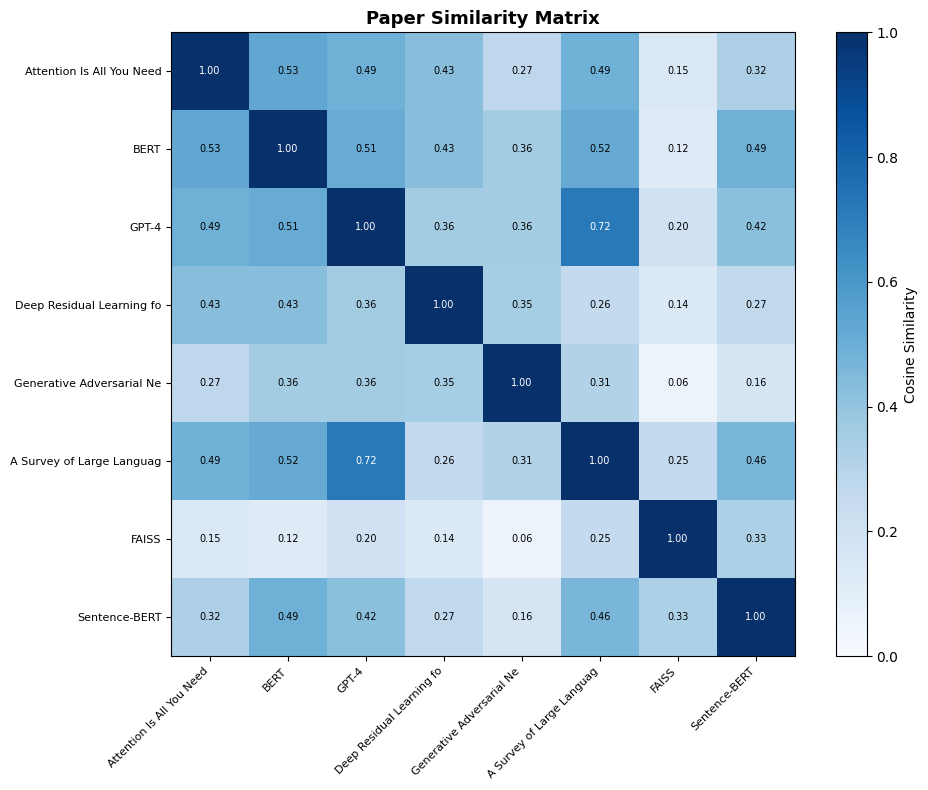

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute pairwise similarity
sim_matrix = cosine_similarity(embeddings)

# Short titles for display
short_titles = [t.split(":")[0][:25] for t in df["title"]]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(short_titles)))
ax.set_yticks(range(len(short_titles)))
ax.set_xticklabels(short_titles, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(short_titles, fontsize=8)

for i in range(len(short_titles)):
    for j in range(len(short_titles)):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}",
               ha="center", va="center", fontsize=7,
               color="white" if sim_matrix[i,j] > 0.6 else "black")
        
plt.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_title("Paper Similarity Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("paper_similarity.png", dpi=300)
plt.show()

## 5. Key Observations

| Paper Pair | Similarity | Reason |
|-----------|-----------|--------|
| GPT-3 vs LLM Survey | 0.72 | Survey covers GPT directly |
| Attention vs BERT | 0.53 | Both transformer-based NLP |
| BERT vs Sentence-BERT | 0.49 | Direct extension of BERT |
| FAISS vs others | ~0.15 | Different domain — vector search |
| GAN vs others | ~0.30 | Generative models, different from NLP |

## Key Insight
Semantic similarity captures topic relationships without keyword matching.
FAISS paper correctly has low similarity to NLP papers — different vocabulary, different domain.

## Use Case
This system can power:
- "Papers like this one" recommendations
- Literature review automation
- Research gap identification

## Next
Extract key claims from paper abstracts.
-> 04_claim_extraction.ipynb